# Deep Autoencoders

Autoencoders are trained on encoding input data such as images into a smaller feature vector, and afterward, reconstruct it by a second neural network, called a decoder. 

The feature vector is referred to as the **“bottleneck”** of the network, as it aims to compress the input data into a smaller number of features. This property is useful in many applications, in particular in compressing data or comparing images on a metric beyond pixel-level comparisons.

In [1]:
## Standard libraries
import os
import json
import math
import numpy as np

## Imports for plotting
import matplotlib
%matplotlib inline
matplotlib.rcParams['lines.linewidth'] = 2.0
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib_inline.backend_inline import set_matplotlib_formats
# For export
set_matplotlib_formats('svg', 'pdf')

import seaborn as sns
sns.reset_orig()
sns.set_theme()

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

## Torchvision
import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms

## PyTorch Lightning
import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

## Tensorboard extension
from torch.utils.tensorboard import SummaryWriter
%load_ext tensorboard

DATASET_PATH = "./data"
CHECKPOINT_PATH = "./saved_models"

# Set the seed
pl.seed_everything(42)

# Deterministic
torch.use_deterministic_algorithms(True)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Device", device)


Seed set to 42


Device mps


In [2]:
import urllib.request
from urllib.error import HTTPError

# Github URL where saved models are stored for this tutorial
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial9/"
# Files to download
pretrained_files = ["cifar10_64.ckpt", "cifar10_128.ckpt", "cifar10_256.ckpt", "cifar10_384.ckpt"]
# Create checkpoint path if it doesn't exist yet
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# For each file, check whether it already exists. If not, try downloading it.
for file_name in pretrained_files:
    file_path = os.path.join(CHECKPOINT_PATH, file_name)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print("Something went wrong. Please try to download the file from the GDrive folder, or contact the author with the full output including the following error:\n", e)

In [ ]:
# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Loading the training dataset
train_dataset = CIFAR10(root=DATASET_PATH, train=True, transform=transform, download=True)
pl.seed_everything(42)
train_set, val_set = torch.utils.data.random_split(train_dataset, [45000, 5000])

# Loading the test dataset
test_set = CIFAR10(root=DATASET_PATH, train=False, transform=transform, download=True)

# Data loaders
train_loader = data.DataLoader(train_set, batch_size=256, shuffle=True, drop_last=True, pin_memory=True, num_workers=4)
val_loader = data.DataLoader(val_set, batch_size=256, shuffle=False, drop_last=False, num_workers=4)
test_loader = data.DataLoader(test_set, batch_size=256, shuffle=False, drop_last=False, num_workers=4)

def get_train_images(num):
    return torch.stack([train_dataset[i][0] for i in range(num)], dim=0)

## Building the autoencoder

In [6]:
class Encoder(nn.Module):
    def __init__(self, num_input_channels: int, base_channel_size: int, latent_dim: int, act_fn: object = nn.GELU):
        super().__init__()
        c_hid = base_channel_size
        self.net = nn.Sequential(
            # 32*32 -> 16*16
            nn.Conv2d(num_input_channels, c_hid, kernel_size=3, padding=1, stride=2),
            act_fn(),
            nn.Conv2d(c_hid, c_hid, kernel_size=3, padding=1),
            act_fn(),
            # 16*16 -> 8*8
            nn.Conv2d(c_hid, 2*c_hid, kernel_size=3, padding=1, stride=2),
            act_fn(),
            nn.Conv2d(2*c_hid, 2*c_hid, kernel_size=3, padding=1),
            act_fn(),
            # 8*8 -> 4*4
            nn.Conv2d(2*c_hid, 2*c_hid, kernel_size=3, padding=1, stride=2),
            act_fn(),
            # Image grid to single feature vector
            nn.Flatten(),
            nn.Linear(2*16*c_hid, latent_dim),
        )
    
    def forward(self, x):
        return self.net(x)

In [7]:
class Decoder(nn.Module):
    def __init__(self, num_input_channels: int, base_channel_size: int, latent_dim: int, act_fn: object = nn.GELU):
        super().__init__()
        c_hid = base_channel_size
        self.linear = nn.Sequential(
            nn.Linear(latent_dim, 2*16*c_hid),
            act_fn(),
        )
        self.net = nn.Sequential(
            # 4*4 -> 8*8
            nn.ConvTranspose2d(2*c_hid, 2*c_hid, kernel_size=3, output_padding=1, padding=1, stride=2),
            act_fn(),
            nn.Conv2d(2*c_hid, 2*c_hid, kernel_size=3, padding=1),
            act_fn(),
            # 8*8 -> 16*16
            nn.ConvTransposed2d(2*c_hid, c_hid, kernel_size=3, output_padding=1, padding=1, stride=2),
            act_fn(),
            nn.Conv2d(c_hid, c_hid, kernel_size=3, padding=1),
            act_fn(),
            # 16*16 -> 32*32
            nn.ConvTransposed2d(c_hid, num_input_channels, kernel_size=3, output_padding=1, padding=1, stride=2),
            # The input images is scaled between -1 and 1, hence the output has to be bounded as well
            nn.Tanh()
        )
    
    def forward(self, x):
        x = self.linear(x)
        x = x.reshape(x.shape[0], -1, 4, 4)
        x = self.net(x)
        return x

In [9]:
class Autoencoder(pl.LightningModule):
    def __init__(self, 
                 base_channel_size: int,
                 latent_dim: int,
                 num_input_channels: int = 3,
                 encoder_class: object = Encoder,
                 decoder_class: object = Decoder,
                 width: int = 32,
                 height: int = 32):
        super().__init__()
        # Saving hyperparameters of autocoder
        self.save_hyperparameters()
        # Creating the encoder and decoder
        self.encoder = encoder_class(num_input_channels, base_channel_size, latent_dim)
        self.decoder = decoder_class(num_input_channels, base_channel_size, latent_dim)
        # Example input array for visualizing the graph of network
        self.example_input_array = torch.zeros(2, num_input_channels, width, height)
    
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

    def _get_reconstruction_loss(self, batch):
        # don't need labels
        x, _ = batch
        x_hat = self.forward(x)
        loss = F.mse_loss(x, x_hat, reduction="none")
        loss = loss.sum(dim=[1,2,3]).mean(dim=[0])
        return loss
    
    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
            mode="min",
            factor=0.2,
            patience=20,
            min_lr=5e-5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": scheduler,
            "monitor": "val_loss"
        }

    def training_step(self, batch, batch_idx):
        loss = self._get_reconstruction_loss(batch)
        self.log("train_loss", loss)
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self._get_reconstruction_loss(batch)
        self.log("val_loss", loss)
    
    def test_step(self, batch, batch_idx):
        loss = self._get_reconstruction_loss(batch)
        self.log("test_loss", loss)


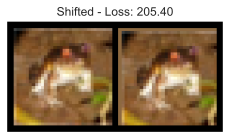

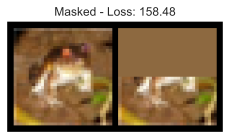

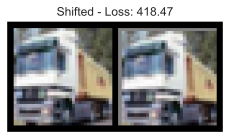

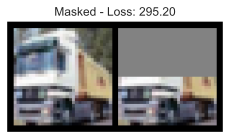

In [12]:
def compare_imgs(img1, img2, title_prefix=""):
    # Calculate MSE loss 
    loss = F.mse_loss(img1, img2, reduction="sum")
    # Plotting
    grid = torchvision.utils.make_grid(torch.stack([img1, img2], dim=0), nrow=2, normalize=True, value_range=(-1, 1))
    grid = grid.permute(1, 2, 0)
    plt.figure(figsize=(4, 2))
    plt.title(f"{title_prefix} Loss: {loss.item():4.2f}")
    plt.imshow(grid)
    plt.axis("off")
    plt.show()

for i in range(2):
    # Load example image
    img, _ = train_dataset[i]
    img_mean = img.mean(dim=[1,2], keepdims=True)

    # Shift image by one pixel
    SHIFT = 1
    img_shifted = torch.roll(img, shifts=SHIFT, dims=1)
    img_shifted = torch.roll(img_shifted, shifts=SHIFT, dims=2)
    img_shifted[:,:1,:] = img_mean
    img_shifted[:,:,:1] = img_mean
    compare_imgs(img, img_shifted, title_prefix="Shifted -")

    # Set half of the image to zero
    img_masked = img.clone()
    img_masked[:,:img_masked.shape[1]//2,:] = img_mean
    compare_imgs(img, img_masked, "Masked -")
    

## Training the model

In [14]:
class GenerateCallback(pl.Callback):
    def __init__(self, input_imgs, every_n_epochs=1):
        super().__init__()
        self.input_imgs = input_imgs
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        if trainer.current_epoch % self.every_n_epochs == 0:
            input_imgs = self.input_imgs.to(pl_module.device)
            # Reconstruct images
            with torch.no_grad():
                pl_module.eval()
                reconst_imgs = pl_module(self.input_imgs)
                pl_module.train()
            imgs = torch.stack([input_imgs, reconst_imgs], dim=1).flatten(0,1)
            grid = torchvision.utils.make_grid(imgs, nrow=2, normalize=True, value_range=(-1, 1))
            trainer.logger.experiment.add_image("Reconstruction", grid, global_step=trainer.global_step)
